# Tensor de inercia

[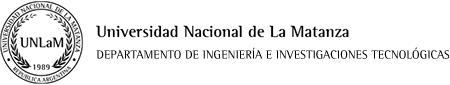](https://ingenieria.unlam.edu.ar/)  
[by-nc-sa_80x15.png](https://creativecommons.org/licenses/by-sa/4.0/deed.es_ES) 
2026 [Víctor A. Bettachini](mailto:vbettachini@unlam.edu.ar)  

---

> ## 🎯 Objetivos
>
> Al completar esta clase, el estudiante podrá:
>
> 1. **Comprender la aproximación de sólido rígido** y su importancia en la simplificación de sistemas de partículas con distancias invariantes.
> 2. **Definir el tensor de inercia** ($I_{ik}$) como un tensor simétrico de segundo orden que caracteriza la distribución de masa de un cuerpo.
> 3. **Calcular la energía cinética de rotación** utilizando notación tensorial y el producto del tensor de inercia por la velocidad angular.
> 4. **Identificar los ejes principales de inercia** mediante la diagonalización del tensor, simplificando el cálculo de los momentos de inercia.
> 5. **Aplicar el Teorema de Steiner (ejes paralelos)** en su forma tensorial para trasladar el cálculo de inercia del centro de masa a cualquier otro punto de referencia.
>
---
> ## 📚 Prerrequisitos
>
> Para aprovechar este cuaderno se asume que el estudiante conoce:
>
> #### Matemática
> - **Álgebra Lineal**: nociones de matrices simétricas, tensores, autovalores y autovectores (diagonalización).
> - **Cálculo integral**: integrales de volumen para el cálculo de masa total y centros de masa.
> - **Notación de sumatoria**: familiaridad con el uso de índices y la delta de Kronecker ($\delta_{ik}$).
>
> #### Física
> - **Cinemática de rotación**: conceptos de velocidad angular ($\vec{\omega}$) y el Teorema del Transporte.
> - **Dinámica de traslación**: cálculo de la energía cinética del centro de masa.
> - **Momentos y torque**: haber completado la lección previa sobre momento angular.
>
> #### Programación / Herramientas
> - **SymPy Avanzado**: manipulación de matrices simbólicas y simplificación de expresiones algebraicas complejas.
> - **Automatización**: se recomienda haber trabajado con las funciones de cálculo de energías desarrolladas a lo largo del curso.
---

## Cuerpo rígido
> **Referencia**  
Secciones $\S$ 31 y $\S$ 32.  
Landau y Lifschitz. Mecánica. 2.a ed. Reverté  
>
**Rígido**: si las **distancias son invariantes** entre puntos del sistema.

Tal cosa no existe: es una aproximación.

Frente al desplazamiento $\Delta \vec{r}$ se desprecian cambios:
- forma
- dimensiones

### Distribución y centro de masa

- Cada diferencial de volúmen $d V$ tiene un $d m$
- Masa total 
$$
m = \int d m (\vec{r}) = \iiint \tilde{\rho}(\vec{r}) dV
$$
- Si no es homogéno la **densidad** $\tilde{\rho}(\vec{r})$ depende de $\vec{r}$
- Centro de masa (centro de inercia)
$$
\vec{r}_{cm} = \frac{1}{m} \iiint \vec{r} \tilde{\rho}(\vec{r}) dV
$$


#### Energía cinética

Si un cuerpo lo desarmaremos en partes diferenciales de masa $d m (\vec{r})$ cada una con velocidad $\dot{\vec{r}}$, la energía cinética total será
$$
T = \int \frac{d m (\vec{r})}{2} \dot{\vec{r}}^2
.
$$

Debe precisarse entonces cuál es $\dot{\vec{r}}$ en un cuerpo en rotación.
Se analizará a través de un ejemplo.

#### Velocidad en un frisbee

Imagine que observa la cara superior de un frisbee mientras vuela horizontal al suelo.
Si se esquematiza un sistema de coordenadas fijo al frisbee y otro fijo al suelo la siguiente figura ilustra la relación entre ambos sistemas.

![arañaFrisbee.png](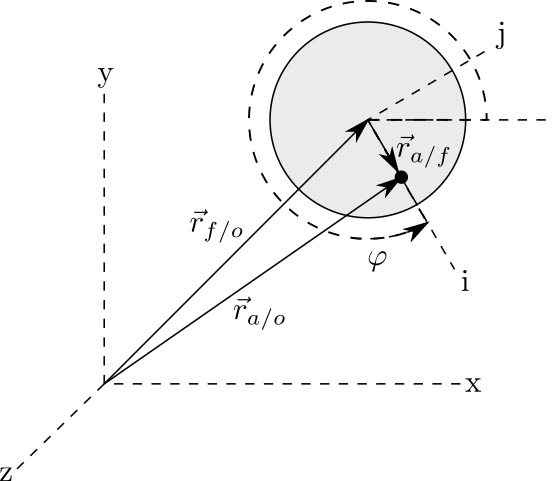 "Sistemas de coordenadas para la araña en el frisbee")

La posición del frisbee en el aire puede ser descrita por un vector posición $\vec{r}_{f/o}$ apuntando al centro de masa del frisbee $f$ desde el origen fijo al suelo $o$.

Para describir una posición sobre el frisbee, podemos imaginar que vuela sobre él una araña $a$, cuya posición relativa al centro de masa del frisbee es dada por un vector $\vec{r}_{a/f}$, y respecto al origen fijo al suelo es dada por un vector $\vec{r}_{a/o}$.

Cuanto rota esta araña con el frisbee lo describe $\varphi$, un ángulo positivo (rotación antihoraria) que es función de la velocidad angular $\dot{\vec{\varphi}} = \frac{d \varphi}{d t} \hat{k}$, un vector orientado hacia arriba (hacia el observador de esta figura).

Para entender como incide en la velocidad de la araña un $\dot{\vec{\varphi}}$ del frisbee puede esquematizarse visualmente como un pequeño cambio en el ángulo $\delta \vec{\varphi}$ produce un también pequeño cambio en la posición de la araña $\delta \vec{r}$.

![lFig5_tan.png](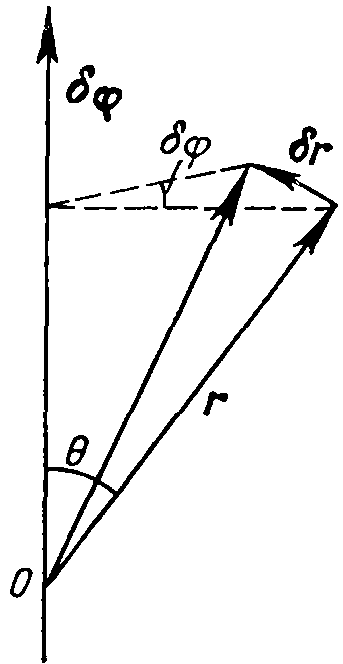 "Cambio de posición ante rotación")

En este esquema puede verse que $\delta \vec{r}$ es perpendicular tanto a $\delta \vec{\varphi}$ al vector posición de la araña respecto a un punto de referencia $\vec{r}$, o más precisamente en el frisbee $\vec{r}_{a/f}$.

En términos diferenciales, el cálculo algebraico del efecto de $d \vec{\varphi} = d \varphi \hat{k}$ es el producto vectorial de estos factores familiarmente conocido como _regla de la mano derecha_ para la rotación
$$
d \vec{r}_{a/f} = d \vec{\varphi} \times \vec{r}_{a/f}
,
$$
donde $\times$ es un producto vectorial que da como resultado otro vector perpendicular a los dos vectores que lo generan.

#### Teorema del transporte
La herramienta algebraica de la _regla de la mano derecha_ facilita el análisis de $\vec{r}_{a/o}$ como suma vectorial de la posición de la araña respecto al centro de rotación del frisbee $\vec{r}_{a/f}$ y de la posición de este respecto al punto fijo en el suelo $\vec{r}_{f/o}$
$$
\begin{aligned}
\vec{r}_{a/o} &= \vec{r}_{f/o} + \vec{r}_{a/f} \\
d \vec{r}_{a/o} &= d \vec{r}_{f/o} + d \vec{\varphi} \times \vec{r}_{a/f} \\
\frac{d }{d t} \vec{r}_{a/o}
&= \frac{d }{d t} \vec{r}_{f/o}  + \frac{d }{d t} \vec{\varphi}  \times \vec{r}_{a/f} \\
\dot{\vec{r}}_{a/o} 
&= \dot{\vec{r}}_{f/o} + \vec{\Omega}_{f/o} \times \vec{r}_{a/f}
\end{aligned}
$$

$$
\boxed{
\dot{ \vec{r} }_o = \frac{\mathrm{d}}{\mathrm{d} t} \vec{r}_o = \frac{\mathrm{d}}{\mathrm{d} t} \vec{R}_P + \vec{\Omega}_{P/o} \times \vec{r}_P = \dot{ \vec{R}}_P + \vec{\Omega}_{P/o} \times \vec{r}_P
}
$$
- $\vec{r}_o$ posición respecto al sistema inercial (suelo)
- $\vec{R}_P$ posición del punto donde pasa el eje de rotación
- $\vec{r}_P$ punto que rota en torno a $\vec{R}_P$ con $\vec{\Omega}_{P/o}$ tal que $\vec{r}_o = \vec{R}_P + \vec{r}_P$

### Energía cinética de un sistema discreto
Elementos finitos: partir en una suma discreta

$$
\begin{aligned}
T
&= \int \frac{d m (\vec{r})}{2} \dot{\vec{r}}^2
\simeq \sum_p \frac{m_p }{2} \dot{\vec{r}_p}^2
= \sum_p \frac{m_p }{2} \left( \dot{ \vec{R}} + \vec{\Omega} \times \vec{r}_p \right)^2 \\
&\simeq 
 \dot{ \vec{R}}^2 \sum_p \frac{m_p }{2}
+ \sum_p m_p \dot{ \vec{R}} \left(  \vec{\Omega} \times \vec{r}_p \right)
+ \sum_p \frac{m_p }{2} \left( \vec{\Omega} \times \vec{r}_p \right)^2
\end{aligned}
$$

El termino del medio se anula si el origen es el centro de masa
$$
\sum_p m_p \dot{ \vec{R}} \left( \vec{\Omega} \times \vec{r}_p \right) = \sum_p m_p \vec{r}_p \left( \dot{ \vec{R}} \times \vec{\Omega} \right) =  \left( \dot{ \vec{R}} \times \vec{\Omega} \right) \sum_p m_p \vec{r}_p = 0
$$

El producto vectorial al cuadrado puede re-escribirse (son muchas cuentas)
$$
\left( \vec{\Omega} \times \vec{r}_p \right)^2
= \left( \vec{\Omega} \times \vec{r}_p \right) \cdot \left( \vec{\Omega} \times \vec{r}_p \right)
=  \vec{\Omega}^2 \vec{r}_p^2 - \left( \vec{\Omega} \cdot \vec{r}_p \right)^2
$$

Puede entonces escribirse la energía cinética
$$
T \simeq \frac{m}{2} \left( \dot{\vec{R} } \right)^2 + \frac{1}{2} \sum_p m_p \left[ \vec{\Omega}^2 \vec{r}_p^2 - \left( \vec{\Omega} \cdot \vec{r}_p \right)^2 \right]
$$

donde el primer término es la desplazamiento (del centro de masa) y el segundo es la que corresponde a la rotación.

### Energía cinética de rotación
Utilizaremos la notación tensorial como alternativa a la vectorial.
- Los vectores se resumen en un único subindice entendiendose que se realiza una suma sobre las tres componentes
    - El vector posición $\vec{r}_p$ se decribe por $r_i$
    - Ídem. $\vec{\Omega}$ se describe por $\Omega_i$
- Al darse por entendida la suma sobre el índice $i$, no se escriben los signos de suma $\sum_i$
    - $\vec{A} \cdot \vec{B} = \sum_i A_i B_i$ se resume en $A_i B_i$
    - $\vec{A}^2 = \vec{A} \cdot \vec{A}$ se resumen en $A_i A_i = A_i^2$
    - $\vec{A}^2 \vec{B}^2 = (\vec{A} \cdot \vec{A}) (\vec{B} \cdot \vec{B})$ se resume en $A_i^2 B_k^2$ donde se utilizan subindices distintos para que no se malinterprete como $( \vec{A} \cdot \vec{B} )^2 = (A_i B_i)^2$ 

En la energía cinética de rotación se escribe $\vec{\Omega}^2 \vec{r}_p^2$ como $\Omega_i^2 r_l^2$ usando el subindice $l$ en $r_l$ para diferenciarlo del $i$ en $\Omega_i$
$$
\begin{aligned}
T_\text{rot}
&\simeq \frac{1}{2} \sum_p m_p \left[ \vec{\Omega}^2 \vec{r}_p^2 - \left( \vec{\Omega} \cdot \vec{r}_p \right)^2 \right]
= \frac{1}{2} \sum_p m_p \left[ \Omega_i^2 r_l^2 - \Omega_i r_i \Omega_k r_k \right] \\
&\simeq \frac{1}{2} \sum_p m_p \left[ \Omega_i \Omega_k \delta_{ik} r_l^2 - \Omega_i \Omega_k r_i r_k \right]
= \frac{1}{2} \Omega_i \Omega_k \sum_p m_p \left[ r_l^2 \delta_{ik} - r_i r_k \right]
\end{aligned}
$$
donde para poder sacar el factor común $\Omega_i \Omega_k$ si hizo uso de la [delta de Kronecker](https://es.wikipedia.org/wiki/Delta_de_Kronecker) $\delta_{ii} =1, \delta_{ik} = 0\,(i \neq k)$ para hacer la substitución $\Omega_i^2 = \Omega_i \Omega_k \delta_{ik}$.

El **tensor de inercia** es la cantidad entre corchetes
$$
I_{ik} = \left[ r_l^2 \delta_{ik} - r_i r_k \right]
$$
en la que $r_l$ debe sumarse sobre las tres componentes vectoriales e $i$ y $k$ son los índices de las respectivas componentes.

### Tensor de inercia
Con el tensor de 2.o orden $I_{ik}$ se calcula $T = \frac{m}{2} \dot{\vec{R}}^2 + \frac{1}{2} I_{ik} \Omega_i \Omega_k$

$$
\overline{\overline{I}}
= I_{ik} = 
\begin{pmatrix}
I_{xx} & I_{xy} & I_{xz} \\
I_{yx} & I_{yy} & I_{yz} \\
I_{zx} & I_{zy} & I_{zz} \\
\end{pmatrix}
=
\begin{pmatrix}
\sum_p m_p (y_p^2 + z_p^2) & - \sum_p m_p x_p y_p & - \sum_p m_p x_p z_p \\
- \sum_p m_p y_p x_p & \sum_p m_p (x_p^2 + z_p^2)  & - \sum_p m_p y_p z_p \\
- \sum_p m_p z_p x_p & - \sum_p m_p z_p y_p & \sum_p m_p (x_p^2 + y_p^2) \\
\end{pmatrix}
$$
- El tensor $\overline{\overline{I}}$ es simétrico
- $I_{xx}, I_{yy}, I_{zz}$: **momentos de inercia**, los otros **productos de inercia**

### Diagonalización de $I_{ik}$
- Los $x_i$ que solo dejan los elementos en la diagonal de $I_{ik}$ son **ejes principales de inercia**, que son los de simetría geométrica del sistema.
En este caso 
$T_\text{rot} = \frac{1}{2} \left( I_1 \Omega_1^2 + I_2 \Omega_2^2 + I_3 \Omega_3^2 \right)$

- Si la rotación se produce en un eje de un sistema $x'_i$ que no pasa por uno centrado en el centro de masa $x_i$ se puede calcular un tensor $I'_{ik}$ a partir del calculado desde el centro de masa $I_{ik}$.

- Esto lleva a la expresión para el [**teorema de ejes paralelos de Steiner**](https://es.wikipedia.org/wiki/Teorema_del_eje_paralelo):
$
I'_{ik} = I_{ik} + M [ a^2 \delta_{ik} - a_i a_k ]
$,
donde $M$ es la masa de todo el sistema y $\vec{a}$ va del origen de este sistema al centro de masa.

Una vez adicionado el **término de Steiner**, y si los ejes del sistema de coordenadas son paralelos a los **ejes principales de inercia**, no habrá productos de inercia en $I_{ik}$.

Para un vector que va desde el origen del sistema de ejes $x'_i$ al centro de masa $\vec{a} = a_x \hat{x} + a_y \hat{y} + a_z \hat{z}$, se tiene que $a^2 = \vec{a} \cdot \vec{a} = a_x^2 + a_y^2 + a_z^2$.
Así el término de Steiner será

$$
M [ a^2 \delta_{ik} - a_i a_k ]
=
\begin{pmatrix}
M (a_y^2 + a_z^2) & - M a_x a_y & - M a_x a_z \\
- M a_y a_x & M (a_x^2 + a_z^2) & - M a_y a_z \\
- M a_z a_x & - M a_z a_y & M (a_x^2 + a_y^2),
\end{pmatrix}
$$
que es también un tensor simétrico. 

### $I_{ik}$ Casos particulares
Si la masa está dispuesta:
- linealmente en $\hat{z} \implies x_p = y_p = 0$
$$
I_{xx} = I_{yy} = \sum_p  m_pz_p^2 \quad I_{zz}= 0
$$

- en un plano $(x,y) \implies z_p = 0$
$$
I_{xx} = \sum_p m_p y_p^2 \quad I_{yy} = \sum_p m_p x_p^2\\
\quad I_{zz} = \sum_p m_p (x_p^2 + y_p^2) = I_{xx} + I_{yy}
$$

### Finalmente, la energía cinética

Ahora hacemos explicita la expresión completa para la energía cinética en notación vectorial
$$
\begin{aligned}
T
= \frac{m}{2} \dot{\vec{R}}^2 + \frac{1}{2} \overline{\overline{I}} \vec{\Omega}^2
= \frac{m}{2} \dot{\vec{R}}^{\mathrm{tr}} \dot{\vec{R}} &+ \frac{1}{2} \vec{\Omega}^{\mathrm{tr}} \overline{\overline{I}} \vec{\Omega}\\
T = \frac{m}{2} 
\begin{pmatrix}
\dot{R}_x & \dot{R}_y & \dot{R}_z \\
\end{pmatrix}
\begin{pmatrix}
\dot{R}_x \\
\dot{R}_y \\
\dot{R}_z \\
\end{pmatrix} 
&+
\frac{1}{2} 
\begin{pmatrix}
\Omega_x &
\Omega_y &
\Omega_z \\
\end{pmatrix} 
\begin{pmatrix}
I_{xx} & I_{xy} & I_{xz} \\
I_{yx} & I_{yy} & I_{yz} \\
I_{zx} & I_{zy} & I_{zz} \\
\end{pmatrix}
\begin{pmatrix}
\Omega_x \\
\Omega_y \\
\Omega_z \\
\end{pmatrix}
\\ 
T = \frac{m}{2} 
\left(
\dot{R}_x^2 + \dot{R}_y^2 + \dot{R}_z^2 
\right) 
&+
\frac{1}{2}
\begin{pmatrix}
\Omega_x &
\Omega_y &
\Omega_z \\
\end{pmatrix} 
\begin{pmatrix}
I_{xx} & I_{xy} & I_{xz} \\
I_{yx} & I_{yy} & I_{yz} \\
I_{zx} & I_{zy} & I_{zz} \\
\end{pmatrix}
\begin{pmatrix}
\Omega_x \\
\Omega_y \\
\Omega_z \\
\end{pmatrix} 
\\ 
\end{aligned}
$$

Si bien esta es la forma general para el tensor $\overline{\overline{I}}$ con una orientación arbitraria, usualmente se hace la rotación que la **diagonaliza**.
Esto se puede hacer con la matriz de rotación que se construye con los autovectores de $\overline{\overline{I}}$ indica la rotación de ejes que se requiere para que en unos nuevos, $\left( \hat{x}', \hat{y}', \hat{z}' \right)$, el sólido presente simetría geométrica.
Tras esa operación la expresión de la energía cinética es más sencilla

$$
\begin{aligned}
T = \frac{m}{2} \dot{\vec{R}}^{\mathrm{tr}} \dot{\vec{R}} &+ \frac{1}{2} \vec{\Omega'}^{\mathrm{tr}} \overline{\overline{I'}} \vec{\Omega'}\\
T = \frac{m}{2} 
\begin{pmatrix}
\dot{R}_x & \dot{R}_y & \dot{R}_z \\
\end{pmatrix}
\begin{pmatrix}
\dot{R}_x \\
\dot{R}_y \\
\dot{R}_z \\
\end{pmatrix}
&+
\frac{1}{2} 
\begin{pmatrix}
\Omega_x' &
\Omega_y' &
\Omega_z' \\
\end{pmatrix} 
\begin{pmatrix}
I_{x'x'} & 0 & 0 \\
0 & I_{y'y'} & 0 \\
0 & 0 & I_{z'z'} \\
\end{pmatrix}
\begin{pmatrix}
\Omega_x' \\
\Omega_y' \\
\Omega_z' \\
\end{pmatrix} 
\\
T = \frac{m}{2} 
\left(
\dot{R}_x^2 + \dot{R}_y^2 + \dot{R}_z^2 
\right) 
&+
\frac{1}{2}
\begin{pmatrix}
\Omega_x' &
\Omega_y' &
\Omega_z' \\
\end{pmatrix} 
\begin{pmatrix}
I_{x'x'} \Omega_x' \\
I_{y'y'} \Omega_y' \\
I_{z'z'} \Omega_z' \\
\end{pmatrix} 
\end{aligned}
$$

$$
\boxed{T = \frac{m}{2} 
\left(
\dot{R}_x^2 + \dot{R}_y^2 + \dot{R}_z^2 
\right) 
+
\frac{1}{2} 
\left(
I_{x'x'} \dot{\Omega}_x'^2 +
I_{y'y'} \dot{\Omega}_y'^2 +
I_{z'z'} \dot{\Omega}_z'^2 
\right)}
$$

pues en el tensor $\overline{\overline{I}}$ solo sobreviven los elementos en la diagonal, los momentos de inercia.